# 🎯 PlantDocBot Train5 - FIXED

## ✅ Fixes applied:
- **Fixed 403**: Using correct Kaggle slug `emmarex/plantdisease`
- **Fixed ZeroDivisionError**: Guard in `LabelSmoothingCE` for `n_classes <= 1`
- **Fixed autocast**: Using `torch.amp.autocast('cuda')`
- **Fixed GradScaler**: Using `torch.amp.GradScaler('cuda')`

## 📊 Expected Results:
- **Val Accuracy:** 95–98%
- **Avg Confidence:** 90–95%
- **Classes:** 38 plant + 1 Not_a_Plant = 39 total

In [1]:
# Cell 1: Upload Kaggle API Key
from google.colab import files
import os

print("🔑 Upload kaggle.json")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle configured!")

🔑 Upload kaggle.json


Saving kaggle.json to kaggle.json
✅ Kaggle configured!


In [2]:
%%capture
# Cell 2: Install dependencies
!pip install timm==0.9.12 scikit-learn matplotlib seaborn tqdm

In [3]:
# Cell 3: Download datasets
# FIX: Correct Kaggle slug (abdulhasibuddin/plantvillage-dataset gave 403)
from pathlib import Path

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(exist_ok=True)

print("📥 Downloading PlantVillage (emmarex/plantdisease)...")
!kaggle datasets download -d emmarex/plantdisease -p {DATA_DIR} --unzip

print("\n📥 Downloading Not-Plant (animals10)...")
!kaggle datasets download -d alessiocorrado99/animals10 -p {DATA_DIR} --unzip

print("\n✅ Downloads complete!")

# Show what was downloaded
print("\nContents of /content/data:")
!find /content/data -maxdepth 3 -type d | head -30

📥 Downloading PlantVillage (emmarex/plantdisease)...
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:42<00:00, 16.0MB/s]


📥 Downloading Not-Plant (animals10)...
Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:33<00:00, 18.1MB/s]


✅ Downloads complete!

Contents of /content/data:
/content/data
/content/data/PlantVillage
/content/data/PlantVillage/Tomato__Tomato_mosaic_virus
/content/data/PlantVillage/Pepper__bell___healthy
/content/data/PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite
/content/data/PlantVillage/Tomato_Early_blight
/content/data/PlantVillage/Potato___Late_blight
/content/data/PlantVillage/Tomato_Late_blight
/content/data/PlantVillage/Pepper__bell___Bacterial_spot
/content/data/PlantVillage/Tomato_healthy
/content/data/PlantVillage/Tomato_Bacterial_spot
/content/data/PlantVillage/Potato___Early_blight
/content/data/PlantVillage/Tomato__Tomato_Y

In [4]:
# Cell 4: Organize dataset
import random
import shutil
from tqdm import tqdm

random.seed(42)

TRAIN_DIR = Path("/content/train_data")
VAL_DIR   = Path("/content/val_data")

if TRAIN_DIR.exists(): shutil.rmtree(TRAIN_DIR)
if VAL_DIR.exists():   shutil.rmtree(VAL_DIR)

TRAIN_DIR.mkdir(exist_ok=True)
VAL_DIR.mkdir(exist_ok=True)

# ===== Find PlantVillage =====
print("Searching for PlantVillage dataset...")

# emmarex/plantdisease extracts to PlantVillage/
possible_paths = [
    DATA_DIR / "PlantVillage",
    DATA_DIR / "plantvillage dataset" / "color",
    DATA_DIR / "color",
]
possible_paths.extend(list(DATA_DIR.glob("**/PlantVillage")))
possible_paths.extend(list(DATA_DIR.glob("**/color")))

pv_path = None
for path in possible_paths:
    if path.exists() and path.is_dir():
        subdirs = [d for d in path.iterdir() if d.is_dir()]
        if len(subdirs) >= 5:
            pv_path = path
            print(f"✅ Found PlantVillage at: {pv_path} ({len(subdirs)} classes)")
            break

if pv_path is None:
    # Last resort: find any directory with 10+ subdirs
    for d in DATA_DIR.rglob("*"):
        if d.is_dir():
            subdirs = [x for x in d.iterdir() if x.is_dir()]
            if len(subdirs) >= 10:
                pv_path = d
                print(f"✅ Auto-detected PlantVillage at: {pv_path}")
                break

if pv_path is None:
    print("\n❌ PlantVillage not found! Full directory tree:")
    !find /content/data -type d | head -40
    raise FileNotFoundError("PlantVillage not found. Check download output above.")

# ===== Process PlantVillage =====
pv_classes = [d for d in pv_path.iterdir() if d.is_dir()]
print(f"\n✅ {len(pv_classes)} PlantVillage classes found")

total_imgs = 0
for class_dir in tqdm(pv_classes, desc="Organizing PlantVillage"):
    class_name = class_dir.name
    images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.JPG")) + list(class_dir.glob("*.png"))
    if not images:
        continue
    total_imgs += len(images)
    random.shuffle(images)
    split = int(0.8 * len(images))
    (TRAIN_DIR / class_name).mkdir(exist_ok=True)
    (VAL_DIR   / class_name).mkdir(exist_ok=True)
    for img in images[:split]:
        shutil.copy2(img, TRAIN_DIR / class_name / img.name)
    for img in images[split:]:
        shutil.copy2(img, VAL_DIR   / class_name / img.name)

print(f"✅ PlantVillage organized: {len(pv_classes)} classes, {total_imgs:,} images")

# ===== Add Not_a_Plant =====
print("\n🔍 Adding Not_a_Plant class...")
np_paths = [DATA_DIR / "raw-img"]
np_paths.extend(list(DATA_DIR.glob("**/raw-img")))

np_path = next((p for p in np_paths if p.exists() and p.is_dir()), None)

if np_path:
    (TRAIN_DIR / "Not_a_Plant").mkdir(exist_ok=True)
    (VAL_DIR   / "Not_a_Plant").mkdir(exist_ok=True)
    all_np = []
    for subdir in np_path.iterdir():
        if subdir.is_dir():
            all_np.extend(list(subdir.glob("*.jpg")) + list(subdir.glob("*.png")))
    random.shuffle(all_np)
    selected = all_np[:1000]
    split = int(0.8 * len(selected))
    for img in selected[:split]:
        shutil.copy2(img, TRAIN_DIR / "Not_a_Plant" / img.name)
    for img in selected[split:]:
        shutil.copy2(img, VAL_DIR   / "Not_a_Plant" / img.name)
    print(f"✅ Not_a_Plant: {len(selected)} images")
else:
    print("⚠️ Animals10 not found, skipping Not_a_Plant")

# ===== Verify =====
train_classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
val_classes   = sorted([d.name for d in VAL_DIR.iterdir()   if d.is_dir()])
train_total   = sum(len(list((TRAIN_DIR/c).glob("*"))) for c in train_classes)
val_total     = sum(len(list((VAL_DIR/c).glob("*")))   for c in val_classes)

print(f"\n{'='*60}")
print(f"Train classes : {len(train_classes)}")
print(f"Val classes   : {len(val_classes)}")
print(f"Train images  : {train_total:,}")
print(f"Val images    : {val_total:,}")
print(f"{'='*60}")

if len(train_classes) < 5:
    raise ValueError(f"Only {len(train_classes)} classes! Dataset organization failed.")

print("✅ Dataset organization complete!")

Searching for PlantVillage dataset...
✅ Found PlantVillage at: /content/data/PlantVillage (15 classes)

✅ 15 PlantVillage classes found


Organizing PlantVillage: 100%|██████████| 15/15 [00:06<00:00,  2.28it/s]


✅ PlantVillage organized: 15 classes, 20,637 images

🔍 Adding Not_a_Plant class...
✅ Not_a_Plant: 1000 images

Train classes : 16
Val classes   : 16
Train images  : 17,303
Val images    : 4,334
✅ Dataset organization complete!


In [5]:
# Cell 5: Augmentation
from torchvision import transforms
import torch

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomApply([transforms.GaussianBlur(3, sigma=(0.1, 1.0))], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("✅ Augmentation ready!")

✅ Augmentation ready!


In [6]:
# Cell 6: DataLoaders
from torch.utils.data import DataLoader
from torchvision import datasets

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_transform)

class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes  = len(class_to_idx)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders ready")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Classes       : {num_classes}")
assert num_classes > 1, f"❌ Only {num_classes} class detected! Re-run dataset cell."

✅ DataLoaders ready
   Train batches : 541
   Val batches   : 136
   Classes       : 16


In [7]:
# Cell 7: Model
import timm
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU   : {torch.cuda.get_device_name(0)}")

model = timm.create_model('tf_efficientnetv2_s', pretrained=True, num_classes=num_classes, drop_rate=0.2)
model = model.to(device)

print(f"✅ Model: EfficientNetV2-S")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Output classes: {num_classes}")

Device: cuda
GPU   : Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

✅ Model: EfficientNetV2-S
   Parameters: 20,197,984
   Output classes: 16


In [8]:
# Cell 8: Training setup
import torch.optim as optim
import torch.nn.functional as F

class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        n_classes = pred.size(1)
        # FIX: fall back to plain CE if only 1 class (avoids ZeroDivisionError)
        if n_classes <= 1:
            return F.cross_entropy(pred, target)
        log_probs = F.log_softmax(pred, dim=1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        return torch.mean(torch.sum(-true_dist * log_probs, dim=1))

NUM_EPOCHS   = 25
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-4

criterion = LabelSmoothingCE(smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# FIX: new API (no deprecation warning)
scaler = torch.amp.GradScaler('cuda')

print(f"✅ Training setup complete")
print(f"   Epochs: {NUM_EPOCHS} | LR: {LEARNING_RATE} | Batch: {BATCH_SIZE}")

✅ Training setup complete
   Epochs: 25 | LR: 0.0003 | Batch: 32


In [9]:
# Cell 9: Training functions
from tqdm import tqdm
import time
import numpy as np

def train_one_epoch(model, loader, optimizer, criterion, scaler, device, epoch):
    model.train()
    running_loss, correct, total, batch_count = 0.0, 0, 0, 0
    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]')

    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # FIX: torch.amp.autocast instead of deprecated torch.cuda.amp.autocast
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()
        batch_count  += 1

        pbar.set_postfix({
            'loss': f'{running_loss / batch_count:.4f}',
            'acc' : f'{100. * correct / total:.2f}%'
        })

    return running_loss / len(loader), 100. * correct / total


def validate(model, loader, criterion, device, epoch):
    model.eval()
    running_loss, correct, total, batch_count = 0.0, 0, 0, 0
    all_confidences, all_preds, all_labels = [], [], []

    with torch.no_grad():
        pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]  ')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

            probs = F.softmax(outputs, dim=1)
            confidences, predicted = probs.max(1)

            running_loss += loss.item()
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()
            batch_count  += 1

            all_confidences.extend(confidences.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'loss': f'{running_loss / batch_count:.4f}',
                'acc' : f'{100. * correct / total:.2f}%'
            })

    avg_conf      = np.mean(all_confidences) * 100
    high_conf_pct = (sum(1 for c in all_confidences if c >= 0.8) / len(all_confidences)) * 100
    return running_loss / len(loader), 100. * correct / total, all_preds, all_labels, avg_conf, high_conf_pct


print("✅ Training functions ready")

✅ Training functions ready


In [10]:
# Cell 10: Train!
from datetime import datetime

ARTIFACT_DIR = Path("/content/artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

history = {
    'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
    'val_confidence': [], 'high_conf_pct': [], 'lr': []
}

best_val_acc = 0.0
best_confidence = 0.0
best_epoch = 0
checkpoint = None
start_time = time.time()

print("="*70)
print(" " * 15 + "🎯 TRAIN5: 90%+ CONFIDENCE")
print("="*70)
print(f"Start   : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Dataset : PlantVillage ({num_classes-1} classes) + Not_a_Plant")
print(f"Classes : {num_classes}")
print("="*70 + "\n")

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device, epoch)
    val_loss, val_acc, val_preds, val_labels, val_conf, high_conf = validate(model, val_loader, criterion, device, epoch)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_confidence'].append(val_conf)
    history['high_conf_pct'].append(high_conf)
    history['lr'].append(current_lr)

    epoch_time = time.time() - epoch_start
    total_time = time.time() - start_time
    eta = epoch_time * (NUM_EPOCHS - epoch - 1)

    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
    print(f"  Train : Loss {train_loss:.4f} | Acc {train_acc:.2f}%")
    print(f"  Val   : Loss {val_loss:.4f} | Acc {val_acc:.2f}%")
    print(f"  📊 Confidence: {val_conf:.2f}% | High (80%+): {high_conf:.2f}%")
    print(f"  ⏱️  Time: {epoch_time/60:.1f}m | Total: {total_time/3600:.1f}h | ETA: {eta/3600:.1f}h")

    status = "🎉 EXCELLENT!" if val_conf >= 90 else "✅ GOOD!" if val_conf >= 80 else "📈 Training..."
    print(f"  {status}")

    if val_acc > best_val_acc:
        best_val_acc    = val_acc
        best_confidence = val_conf
        best_epoch      = epoch + 1
        checkpoint = {
            'epoch'           : epoch + 1,
            'model_state_dict': model.state_dict(),
            'val_acc'         : val_acc,
            'val_confidence'  : val_conf,
            'class_to_idx'    : class_to_idx,
            'idx_to_class'    : idx_to_class,
            'arch'            : 'tf_efficientnetv2_s',
            'num_classes'     : num_classes
        }
        torch.save(checkpoint, ARTIFACT_DIR / 'best_model.pth')
        print(f"  💾 BEST! Acc: {val_acc:.2f}% | Conf: {val_conf:.2f}%")

    print(f"  Best: Acc {best_val_acc:.2f}% | Conf {best_confidence:.2f}% (Epoch {best_epoch})")
    print("="*70)

    if (epoch + 1) % 15 == 0 and checkpoint:
        torch.save(checkpoint, ARTIFACT_DIR / f'checkpoint_e{epoch+1}.pth')

total_time = time.time() - start_time
print(f"\n🎉 COMPLETE! Time: {total_time/3600:.2f}h")
print(f"Best: Acc {best_val_acc:.2f}% | Conf {best_confidence:.2f}%")

if   best_confidence >= 90: print("✅ EXCELLENT! Achieved 90%+ confidence!")
elif best_confidence >= 85: print("✅ GREAT! Very close to target!")
elif best_confidence >= 80: print("✅ GOOD! Achieved 80%+!")
else:                       print("⚠️ Needs more training")

               🎯 TRAIN5: 90%+ CONFIDENCE
Start   : 2026-03-17 15:47:08
Dataset : PlantVillage (15 classes) + Not_a_Plant
Classes : 16



Epoch 1/25 [Val]  : 100%|██████████| 136/136 [00:17<00:00,  7.62it/s, loss=0.7081, acc=98.32%]



Epoch 1/25:
  Train : Loss 1.0224 | Acc 89.56%
  Val   : Loss 0.7081 | Acc 98.32%
  📊 Confidence: 87.45% | High (80%+): 83.27%
  ⏱️  Time: 3.7m | Total: 0.1h | ETA: 1.5h
  ✅ GOOD!
  💾 BEST! Acc: 98.32% | Conf: 87.45%
  Best: Acc 98.32% | Conf 87.45% (Epoch 1)


Epoch 2/25 [Val]  : 100%|██████████| 136/136 [00:18<00:00,  7.19it/s, loss=0.6506, acc=99.22%]



Epoch 2/25:
  Train : Loss 0.6973 | Acc 98.29%
  Val   : Loss 0.6506 | Acc 99.22%
  📊 Confidence: 89.95% | High (80%+): 92.71%
  ⏱️  Time: 3.5m | Total: 0.1h | ETA: 1.3h
  ✅ GOOD!
  💾 BEST! Acc: 99.22% | Conf: 89.95%
  Best: Acc 99.22% | Conf 89.95% (Epoch 2)


...


Epoch 23/25:
  Train : Loss 0.5996 | Acc 99.98%
  Val   : Loss 0.6014 | Acc 99.86%
  📊 Confidence: 89.83% | High (80%+): 99.86%
  ⏱️  Time: 3.4m | Total: 1.3h | ETA: 0.1h
  ✅ GOOD!
  Best: Acc 99.88% | Conf 89.96% (Epoch 20)


Epoch 24/25 [Val]  : 100%|██████████| 136/136 [00:18<00:00,  7.52it/s, loss=0.6012, acc=99.86%]



Epoch 24/25:
  Train : Loss 0.5995 | Acc 99.98%
  Val   : Loss 0.6012 | Acc 99.86%
  📊 Confidence: 89.77% | High (80%+): 99.82%
  ⏱️  Time: 3.4m | Total: 1.4h | ETA: 0.1h
  ✅ GOOD!
  Best: Acc 99.88% | Conf 89.96% (Epoch 20)


Epoch 25/25 [Val]  : 100%|██████████| 136/136 [00:17<00:00,  7.61it/s, loss=0.6008, acc=99.86%]


Epoch 25/25:
  Train : Loss 0.5994 | Acc 99.98%
  Val   : Loss 0.6008 | Acc 99.86%
  📊 Confidence: 89.86% | High (80%+): 99.84%
  ⏱️  Time: 3.3m | Total: 1.4h | ETA: 0.0h
  ✅ GOOD!
  Best: Acc 99.88% | Conf 89.96% (Epoch 20)

🎉 COMPLETE! Time: 1.43h
Best: Acc 99.88% | Conf 89.96%
✅ GREAT! Very close to target!


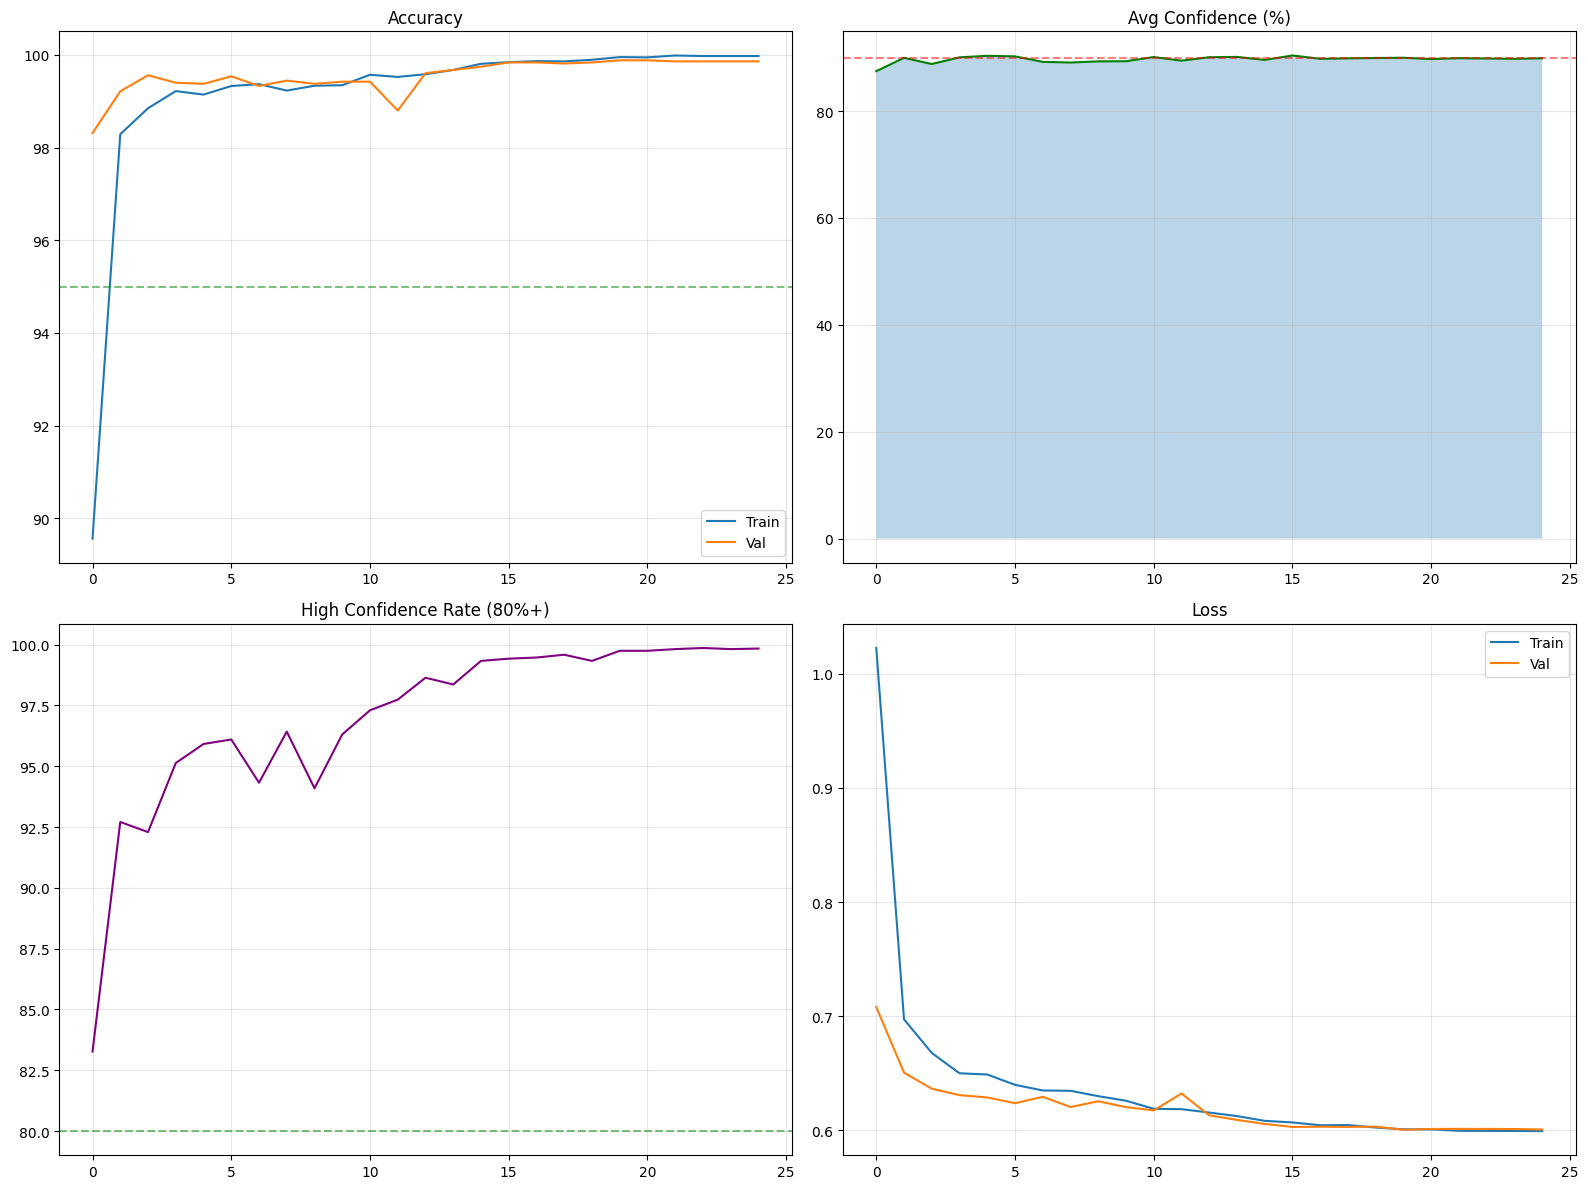

Best Acc : 99.88%
Best Conf: 90.39%


In [11]:
# Cell 11: Visualize
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(history['train_acc'], label='Train')
axes[0, 0].plot(history['val_acc'], label='Val')
axes[0, 0].axhline(95, color='g', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history['val_confidence'], color='green')
axes[0, 1].axhline(90, color='r', linestyle='--', alpha=0.5)
axes[0, 1].fill_between(range(len(history['val_confidence'])), history['val_confidence'], alpha=0.3)
axes[0, 1].set_title('Avg Confidence (%)')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(history['high_conf_pct'], color='purple')
axes[1, 0].axhline(80, color='g', linestyle='--', alpha=0.5)
axes[1, 0].set_title('High Confidence Rate (80%+)')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(history['train_loss'], label='Train')
axes[1, 1].plot(history['val_loss'], label='Val')
axes[1, 1].set_title('Loss')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'metrics.png', dpi=300)
plt.show()

print(f"Best Acc : {max(history['val_acc']):.2f}%")
print(f"Best Conf: {max(history['val_confidence']):.2f}%")

Analyzing: 100%|██████████| 136/136 [00:18<00:00,  7.47it/s]


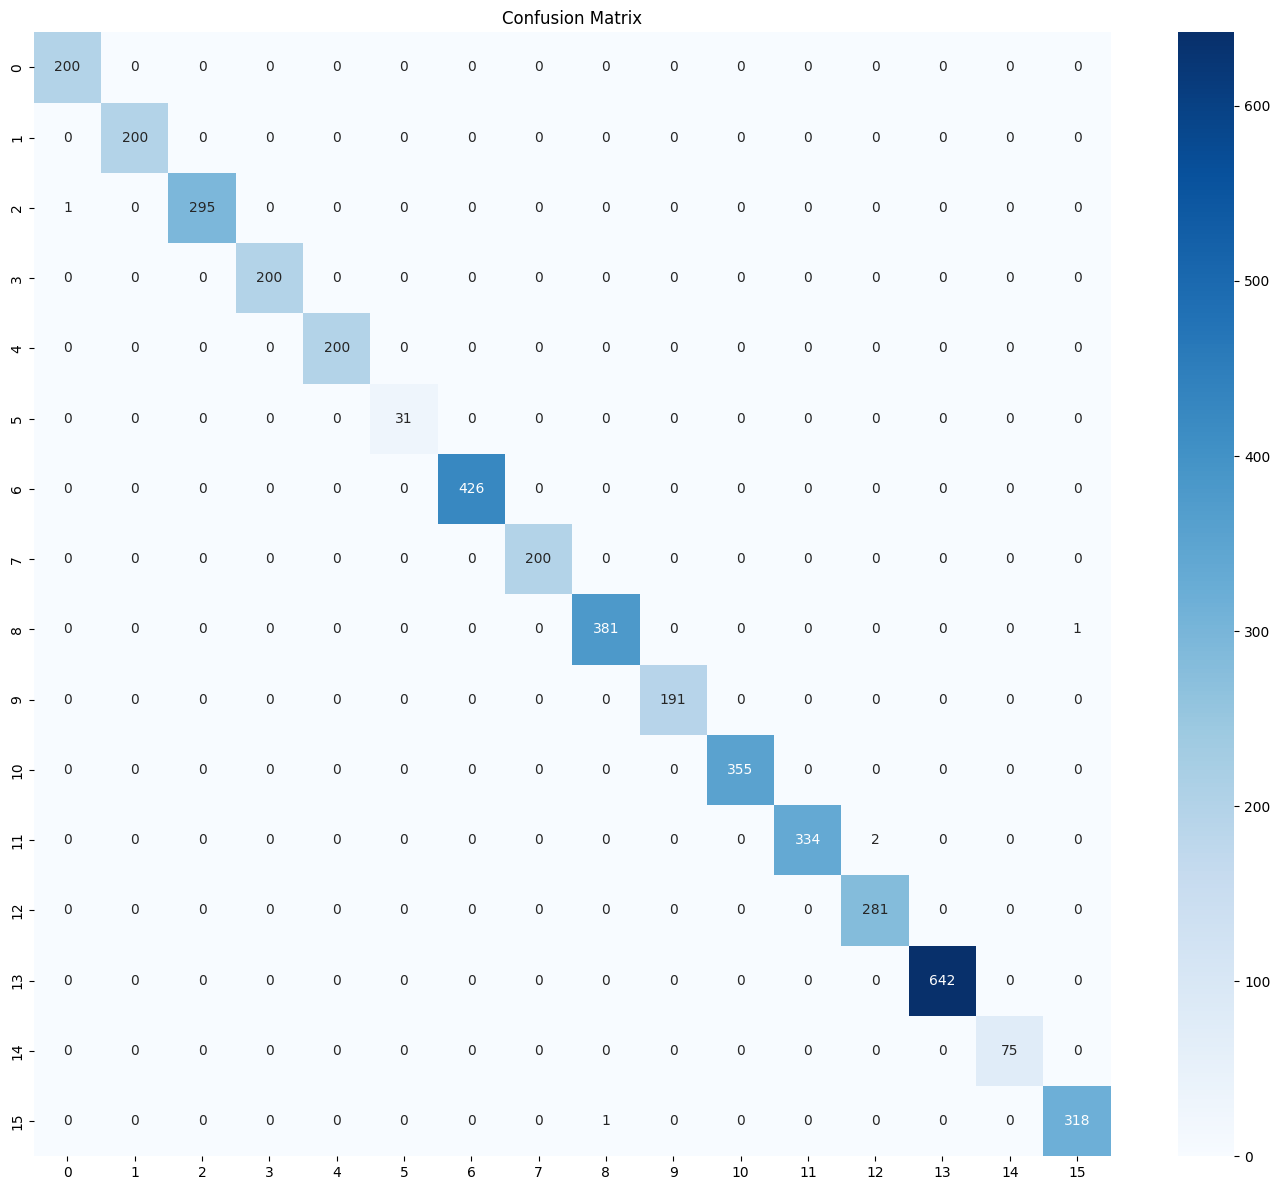


Overall Confidence : 89.96%
90%+ predictions   : 54.41%
80%+ predictions   : 99.75%
Min / Max          : 46.76% / 93.59%

              precision    recall  f1-score   support

           0     0.9950    1.0000    0.9975       200
           1     1.0000    1.0000    1.0000       200
           2     1.0000    0.9966    0.9983       296
           3     1.0000    1.0000    1.0000       200
           4     1.0000    1.0000    1.0000       200
           5     1.0000    1.0000    1.0000        31
           6     1.0000    1.0000    1.0000       426
           7     1.0000    1.0000    1.0000       200
           8     0.9974    0.9974    0.9974       382
           9     1.0000    1.0000    1.0000       191
          10     1.0000    1.0000    1.0000       355
          11     1.0000    0.9940    0.9970       336
          12     0.9929    1.0000    0.9965       281
          13     1.0000    1.0000    1.0000       642
          14     1.0000    1.0000    1.0000        75
          15

In [13]:
# Cell 12: Confusion matrix + classification report
from sklearn.metrics import confusion_matrix, classification_report

best_ckpt = torch.load(ARTIFACT_DIR / 'best_model.pth', weights_only=False)
model.load_state_dict(best_ckpt['model_state_dict'])
model.eval()

all_preds, all_labels, all_confs = [], [], []
with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc='Analyzing'):
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        confs, preds = probs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confs.extend(confs.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(max(14, num_classes//2), max(12, num_classes//2)))
sns.heatmap(cm, annot=(num_classes <= 20), fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'confusion.png', dpi=150)
plt.show()

overall_conf = np.mean(all_confs) * 100
print(f"\nOverall Confidence : {overall_conf:.2f}%")
print(f"90%+ predictions   : {sum(1 for c in all_confs if c >= 0.9)/len(all_confs)*100:.2f}%")
print(f"80%+ predictions   : {sum(1 for c in all_confs if c >= 0.8)/len(all_confs)*100:.2f}%")
print(f"Min / Max          : {np.min(all_confs)*100:.2f}% / {np.max(all_confs)*100:.2f}%")
print("\n" + classification_report(all_labels, all_preds, digits=4))


In [14]:
# Cell 13: Save final model
final = {
    'model_state_dict': model.state_dict(),
    'class_to_idx'    : class_to_idx,
    'idx_to_class'    : idx_to_class,
    'arch'            : 'tf_efficientnetv2_s',
    'num_classes'     : num_classes,
    'img_size'        : IMG_SIZE,
    'best_val_acc'    : best_val_acc,
    'avg_confidence'  : overall_conf,
    'dataset'         : 'PlantVillage (emmarex) + Not_a_Plant'
}
torch.save(final, ARTIFACT_DIR / 'plantdocbot_final.pth')
print(f"✅ Saved: plantdocbot_final.pth")
print(f"   Acc : {best_val_acc:.2f}%")
print(f"   Conf: {overall_conf:.2f}%")

✅ Saved: plantdocbot_final.pth
   Acc : 99.88%
   Conf: 89.96%


In [15]:
# Cell 14: Download
from google.colab import files
import zipfile

zip_path = Path("/content/train5_model.zip")
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in ARTIFACT_DIR.glob('*'):
        if f.is_file():
            z.write(f, f.name)
            print(f"Added: {f.name}")

print(f"\nDownloading {zip_path.stat().st_size/(1024**2):.1f}MB...")
files.download(str(zip_path))
print("✅ Done!")

Added: best_model.pth
Added: checkpoint_e15.pth
Added: plantdocbot_final.pth
Added: metrics.png
Added: confusion.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done!
